## Module 4: Cancer

## Team Members:
Amelia Luongo and Christina Johnson

## AI Usage
Generative AI was used to assist with code writing and debugging.

## Invasion and Metastasis in Gynecological Cancers: An RNA-seq Analysis of Gene Expression in Breast, Ovarian, Cervical, and Uterine Tumors




## Project Goal:
This project seeks to explore how history of hormonal contraceptive use impacts the potential metastasis of female specific cancers (breast, uterine, ovarian, and cervical). It aims to classify gynecological cancers based on the expression of different genes associated with invasion and metastasis.


## Disease Background:


* Cancer hallmark focus: Invasion and Metastasis
* Overview of hallmark: A cancer metastasizes when it spreads to other regions of the body apart from where the original tumor was located. Cancer cells can detach from the main tumor and enter the circulation system leading them to different organs. These cancer cells can colonize in a new location and continue to invade into surrounding tissue, creating secondary tumors througnout the body. This is a key trait of cancer that is used to diagnose stage IV.
* Genes associated with hallmark to be studied:  This hallmark will be investigated in relation to womens health and common cancer types women experience. This includes the BRCA gene for breast cancer, TP53 for cervical and ovarian cancer, and PTEN for uterine cancers. 

* Prevalence & incidence
    - Breast cancer: 316,950 new cases per year in the US
    - Ovarian cancer: 20,890 new cases per year in the US
    - Cervical cancer: 13,360 new cases per year in the US
    - Uterine cancer: 69,120 new cases per year in the US
* Risk factors (genetic, lifestyle) & Societal determinants
    - This analysis will compare the history of hormonal contraceptive usage with severity of cancer
    - Many of these cancer types can have genetic risk factors
    - Other diagnoses like PCOS and endometriosis indicate a higher risk for ovarian or uterine cancer
    - HPV is a main risk factor for cervical cancer
* Standard of care treatments (& reimbursement) 
    - Many of the treatments for these cancers are similar to all other cancer protocols. Combinations of chemotherapy, radiation, and surgery are used to target the cancer cells. 
    - Screening and prevention is encouraged through regular mammograms, pap smears, and HPV screenings. 
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)
    - Like all cancers, they arise from genetic mutations that contain enough cancer hallmarks to grow out of control. Some of the cancers, such as cervical cancer, are also driven by viruses like HPV. These viruses can damage some of the internal checkpoints cells have to ensure mutations do not compile. Finally, cancers that are affected by hormones, such as endometriosis impacting uterine cancer, have cells that replicate very rapidly due to additional stimulation from these unbalanced hormones. 


https://seer.cancer.gov/statfacts/html/ovary.html


## Data-Set: 

This project uses RNA sequencing (RNA-seq) data from The Cancer Genome Atlas (TCGA) which was re-processed by Rahman et al. RNA-seq is a sequencing technique that measures gene expression by calculating the amount of mRNA present in tumor samples. This process allows one to compare how active specific genes are across different types of cancers.

The dataset includes 24 cancer types, but this analysis will focus on those related to women’s health: cervical cancer (CESC), ovarian cancer (OV), breast cancer (BRCA), uterine endometrial cancer (UCEC), and uterine carcinosarcoma (UCS). The dataset was subsetted to include approximately 50-100 tumor samples for each cancer type (a total of 1,802 samples). In addition to gene expression data, the dataset includes clinical metadata such as patient characteristics and clinical history. For this project, the analysis will focus specifically on relevant variables such as cancer type and hormonal contraceptive usage.

This project analyzed genes specfically associated with the invasion and metastasis of the cancers indicated above. The key genes include:
 - BRCA1 and BRCA2 (breast cancer)²
 - TP53 (ovarian cancer & Uterine Carcinosarcoma)⁴
 - TGA5, HHEX & S1PR4 (cervical Cancer)⁵
 - GINS4 & PTEN (uterine endometrial cancer)¹

By comparing the gene expression across these cancer types and other clinical data, these datasets allows us to investigate how these genes may contribute to the cancer severity, progression, and metastasis.



## Data Analysis: 

### 1. Methods
The machine learning techniques we are using are unsupervised learning methods including principal component analysis (PCA), K-means clustering, and UMAP visualization. The PCA uses dimensionality reduction to capture variance between the genes we are analyzing within specific cancer types and history of hormonal contraceptive use in relation to cancer metastasis. The k-means clustering then groups the data in patterns based on gene expression. The two graphs can be compared to see if the unlabeles groups that form during k-clustering match the sections from each cancer type on the original PCA. The UMAP visualization distinguishes the gene expression of the cancer types without having to adhere to a linear model. This is helpful for this data set as it has non-linear data with many features. 


### 2. Analysis


#### 2a. Data Preprocessing and Subsetting
First, the data set is read and loaded into a data frame before further analysis. The data is then subset based on the 5 specific cancer types being evaluated (CESC, OV, BRCA, UCEC, and UCS). Next, the list of all genes related to our hallmark of interest (invasion and metastasis) is subsetted as well. This leaves 596 genes of interest remaining. 

In [17]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

data = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
metadata_df = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
# Subset the data for a specific cancer type

cancer_type = ['CESC', 'OV', 'BRCA', 'UCEC', 'UCS']

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'].isin(cancer_type)].index
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
cancer_data = data[cancer_samples]

# Subset by index (genes)

# Load gene list from Menyhart hallmarks file and extract metastasis row
hallmarks = {}
with open('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/Menyhart_JPA_CancerHallmarks_core.csv') as f:
    for line in f:
        parts = line.strip().strip('"').split('\t')
        hallmarks[parts[0]] = parts[1:]

desired_gene_list = hallmarks['TISSUE INVASION AND METASTASIS']

gene_list = [gene for gene in desired_gene_list if gene in cancer_data.index]

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
cancer_gene_data = cancer_data.loc[gene_list]


print(f"\nTotal: {len(gene_list)} genes")





Total: 596 genes


#### 2b. Merging Gene Expression Data with Clinical Metadata
The following code merges the data into one data frame that can be analyzed using different machine learning techniques. It creates one table that includes gene expression values and the metadata that compares cancer types and contraceptive use. SNAI1 is one of the key genes involved in the invasion and metastasis of cancers. The graphs below compare that metastasis gene expression across the 5 cancers being investigated as well as in people who have used hormonal birth control vs those who have not. The last graph narrows down 3 cancers (both uterine and cervical) and shows the gene expression based on history of hormonal contraceptive. 

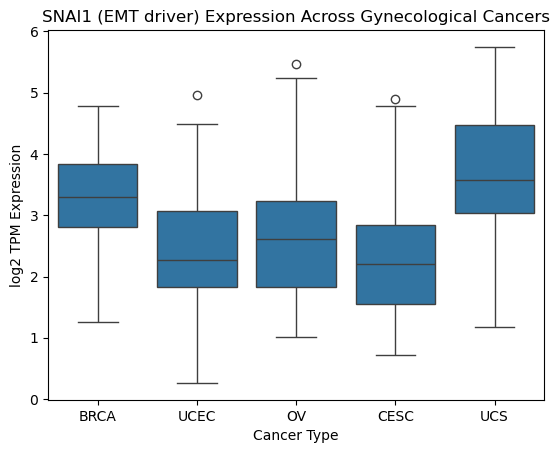

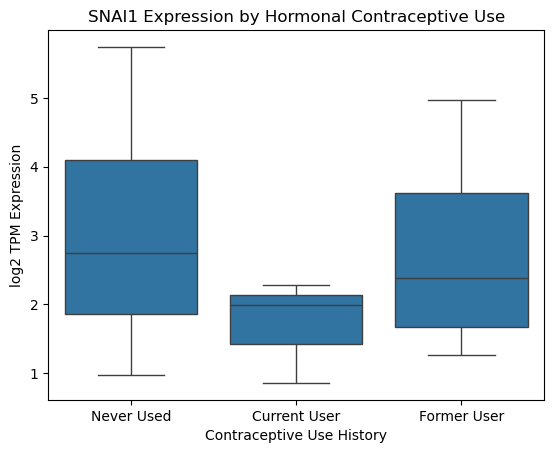

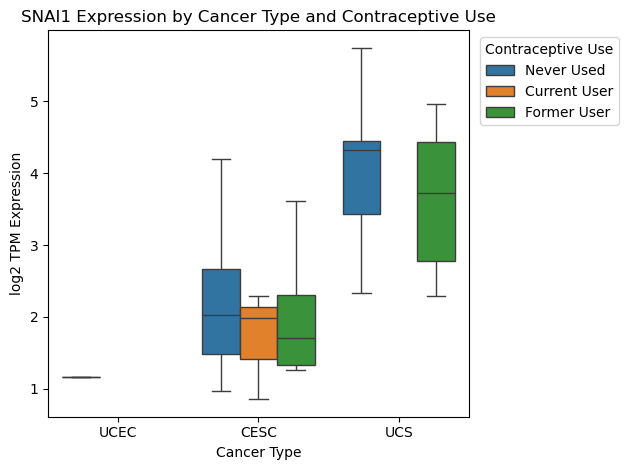

In [10]:

# Merging datasets

# Merge the subsetted expression data with metadata for BRCA samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
cancer_metadata = metadata_df.loc[cancer_samples]
cancer_merged = cancer_gene_data.T.merge(
    cancer_metadata, left_index=True, right_index=True)


# Plotting - Gene expression across cancer types


# Boxplot of a key metastasis gene across cancer types
sns.boxplot(data=cancer_merged, x='cancer_type', y='SNAI1')
plt.title('SNAI1 (EMT driver) Expression Across Gynecological Cancers')
plt.xlabel('Cancer Type')
plt.ylabel('log2 TPM Expression')
plt.show()

# Boxplot of key metastasis gene by contraceptive use
# Filter out unknown to focus on samples with actual data
known_hormone = cancer_merged[cancer_merged['history_hormonal_contraceptives_use'].isin(['Never Used', 'Former User', 'Current User'])]

sns.boxplot(data=known_hormone, x='history_hormonal_contraceptives_use', y='SNAI1')
plt.title('SNAI1 Expression by Hormonal Contraceptive Use')
plt.xlabel('Contraceptive Use History')
plt.ylabel('log2 TPM Expression')
plt.show()

# Boxplot comparing contraceptive use AND cancer type together
sns.boxplot(data=known_hormone, x='cancer_type', y='SNAI1', hue='history_hormonal_contraceptives_use')
plt.title('SNAI1 Expression by Cancer Type and Contraceptive Use')
plt.xlabel('Cancer Type')
plt.ylabel('log2 TPM Expression')
plt.legend(title='Contraceptive Use', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()



SNAI1 expression mainly varies by cancer type, with higher levels in UCS and BRCA suggesting more metastatic activity, while CESC and UCEC are lower and more consistent. In comparison, contraceptive use groups largely overlap, showing no strong effect. Overall, the patterns seem driven more by cancer type than contraceptive history, suggesting cancer biology plays the bigger role, with any contraceptive effects likely small.

#### 2c. PCA Visualization and Interpretation
Dimensionalilty reduction using a PCA shows patterns within the data that can separate key characteristics being looked at. The first graph compares gene expression between the 5 different types of cancers. It can show if the cancers are distinguishable on their own before introducing the contraceptive comparisons. The second PCA is then colored based on hormonal contraceptive history. If the groups showed distinct clusters it could indicate a correlation between contraceptive use and metastasis, but it is hard to draw distinct conclusions due to the high volume of unknown histories. 

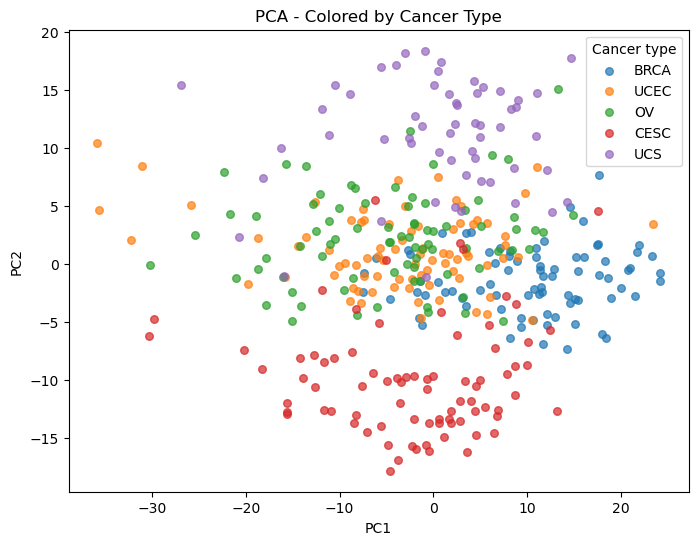

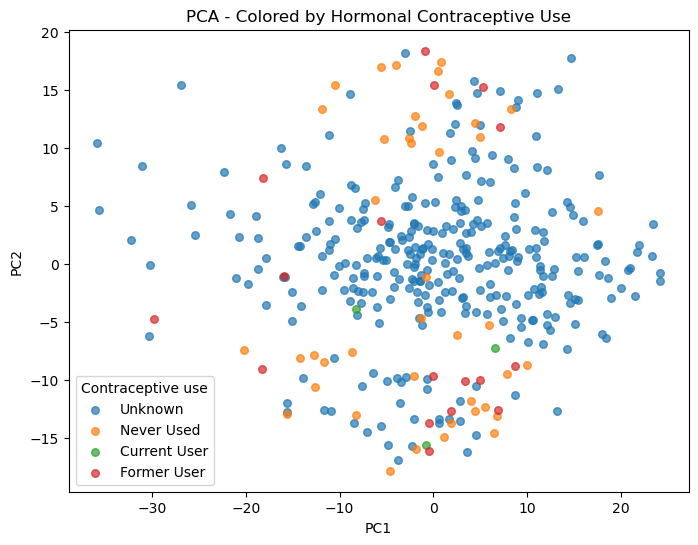

In [11]:

# Prepare data for PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Transpose so rows=samples, columns=genes, then scale
X = cancer_gene_data.T
X_scaled = StandardScaler().fit_transform(X)


# Run PCA and plot - colored by cancer type

X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

cancer_labels = metadata_df.loc[X.index, 'cancer_type']

fig, ax = plt.subplots(figsize=(8, 6))
for ctype in cancer_labels.unique():
    mask = cancer_labels == ctype
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=ctype, alpha=0.7, s=30)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA - Colored by Cancer Type')
ax.legend(title='Cancer type')
plt.show()


# PCA - colored by hormonal contraceptive use

hormone_labels = metadata_df.loc[X.index, 'history_hormonal_contraceptives_use']
hormone_labels = hormone_labels.fillna('Unknown').replace(['[Not Available]', '[Unknown]'], 'Unknown')

fig, ax = plt.subplots(figsize=(8, 6))
for val in hormone_labels.unique():
    mask = hormone_labels == val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=val, alpha=0.7, s=30)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA - Colored by Hormonal Contraceptive Use')
ax.legend(title='Contraceptive use')
plt.show()

PCA shows partial clustering by cancer type, meaning gene expression captures biological differences, though overlap suggests shared features between cancers.

No clear clustering by contraceptive use, indicating it does not strongly influence overall gene expression patterns. However there seems to be a slight pattern of unknown being grouped in the middle while the known data is group toward the top and bottom of the graph

#### 2d. K-Means Clustering
K-means clustering finds groups within the data that naturally form clusters. It is useful in this context to identify unlabeled groups with similarities. In comparison with the groupings formed by coloring the PCA by cancer type, the clusters seem to appear in similar regions. This indicated that the metastasis gene expression is somewhat distinct between the cancer types. It is an efficient way to preserve patterns in a data set with many features. 

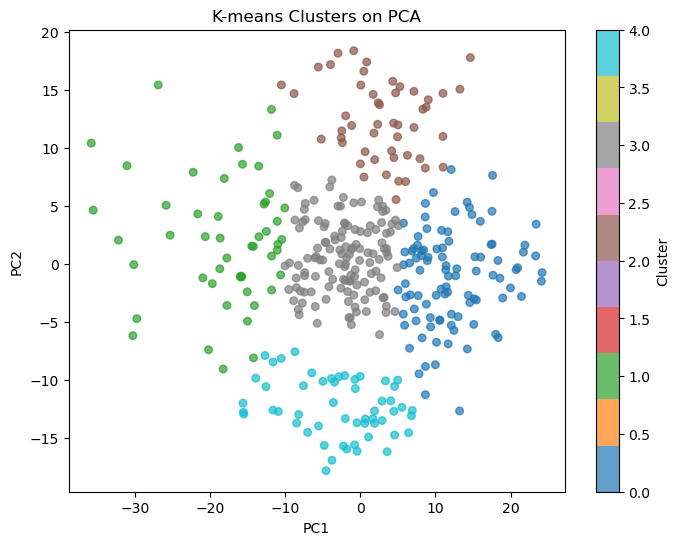

In [12]:

# K-means clustering on PCA

from sklearn.cluster import KMeans

km = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_pca)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7, s=30)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-means Clusters on PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()


Clusters roughly align with cancer types, supporting that gene expression distinguishes cancers, though overlap remains.

#### 2d. Nonlinear Dimensionality Reduction Using UMAP
This code applies UMAP to reduce the data into two dimensions to be viewed in a simpler format. Each cancer type is assigned a color to visualize the non-linear relationship between the groups. This is an improvement from the original PCA as it shows the groups in distinct regions instead of following a linear regression. 

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


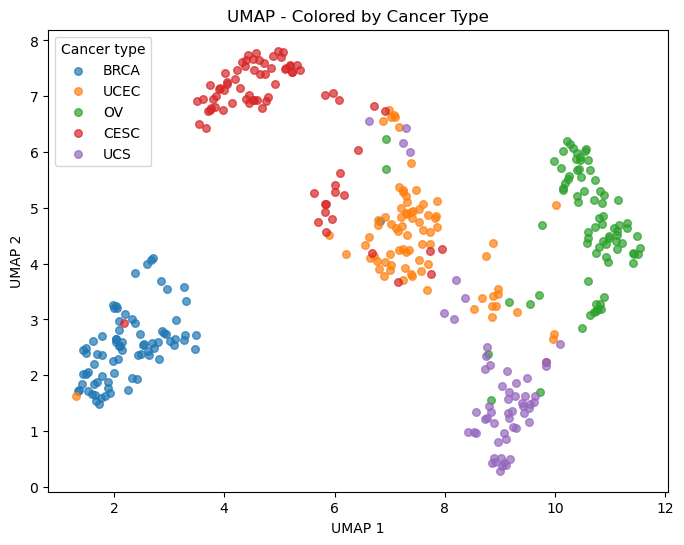

In [13]:

# UMAP

import umap

X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for ctype in cancer_labels.unique():
    mask = cancer_labels == ctype
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], label=ctype, alpha=0.7, s=30)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP - Colored by Cancer Type')
ax.legend(title='Cancer type')
plt.show()


UMAP shows clearer separation than PCA, suggesting non-linear patterns better distinguish cancer types and support classification.

#### 2e. Supervised Learning: Decision Tree Classification & Confusion matrix 
Using a supervised learning model, decision tree classification, to predict cancer type based on expression of genes involved in invasion and metastasis. 

We evaluate performance using accuracy and a confusion matrix, which shows how often each cancer type is correctly or incorrectly predicted. This helps us see which cancers the model predicts well and which ones it confuses.

Training samples  : 377
Validation samples: 320
Features (genes)  : 596

In-sample  error  (training)  : 0.0902  (9.02%)
Out-of-sample error (validation): 0.2344  (23.44%)

In-sample  accuracy : 0.9098
Out-of-sample accuracy: 0.7656


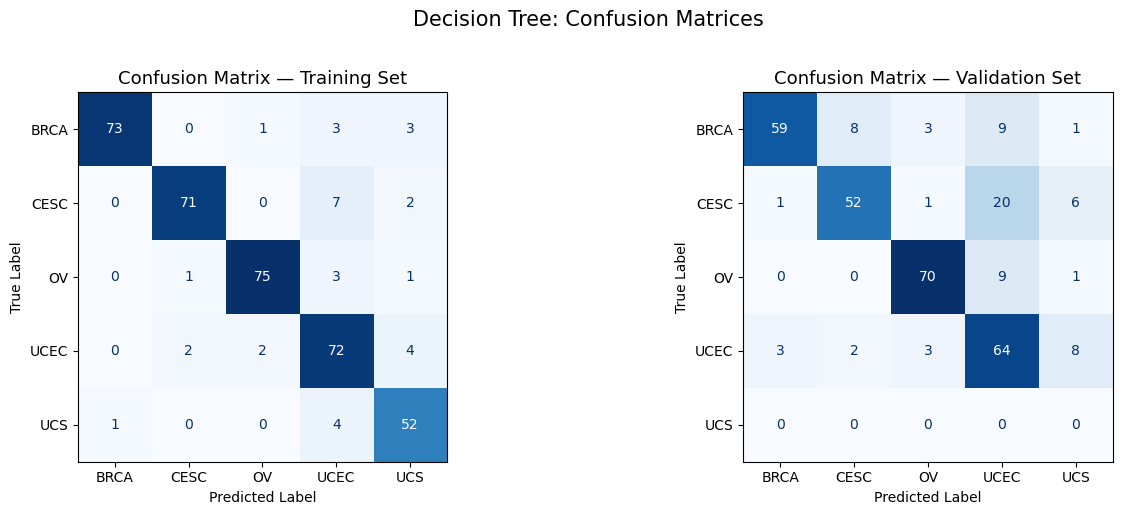


Classification Report — Validation Set
              precision    recall  f1-score   support

        BRCA       0.94      0.74      0.83        80
        CESC       0.84      0.65      0.73        80
          OV       0.91      0.88      0.89        80
        UCEC       0.63      0.80      0.70        80
         UCS       0.00      0.00      0.00         0

    accuracy                           0.77       320
   macro avg       0.66      0.61      0.63       320
weighted avg       0.83      0.77      0.79       320



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


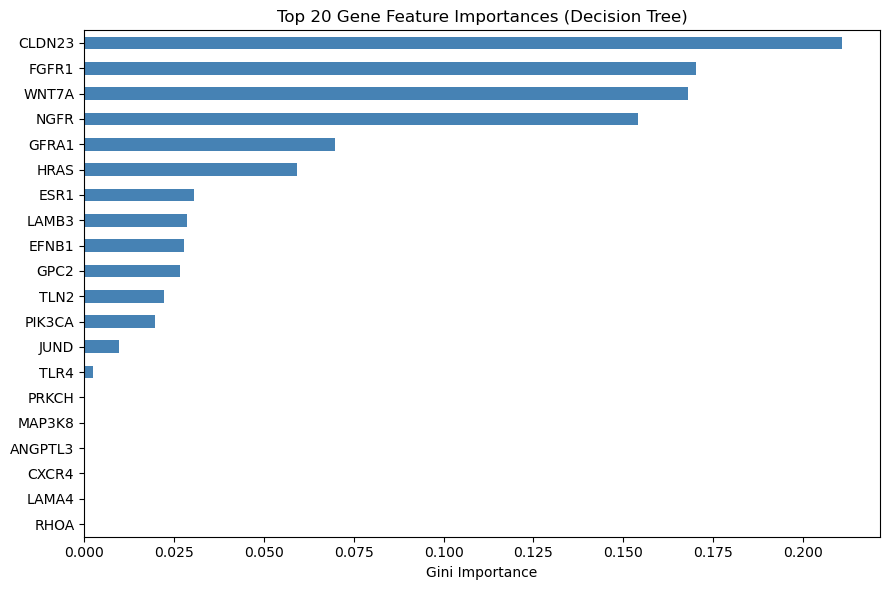

In [ ]:

# DECISION TREE CLASSIFICATION


from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the true validation set 
val_data = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
val_metadata = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/VALIDATION_SET_GSE62944_metadata.csv', index_col=0, header=0)

#2. Subset validation set to same cancer types & genes 
val_cancer_samples = val_metadata[val_metadata['cancer_type'].isin(cancer_type)].index
val_cancer_data = val_data[val_cancer_samples]
val_gene_data = val_cancer_data.loc[gene_list]   # same metastasis genes as training

# 3. Prepare training features and labels
scaler = StandardScaler()
X_train = scaler.fit_transform(cancer_gene_data.T)   # fit ONLY on training data
X_val   = scaler.transform(val_gene_data.T)          # transform only, no refit

y_train = metadata_df.loc[cancer_gene_data.T.index, 'cancer_type'].values
y_val   = val_metadata.loc[val_gene_data.T.index, 'cancer_type'].values

print(f"Training samples  : {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Features (genes)  : {X_train.shape[1]}")

# 4. Fit Decision Tree on full training set 
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

# 5. Predictions
y_train_pred = dt.predict(X_train)
y_val_pred   = dt.predict(X_val)

# 6. Error rates 
train_error = 1 - accuracy_score(y_train, y_train_pred)
val_error   = 1 - accuracy_score(y_val,   y_val_pred)

print(f"\nIn-sample  error  (training)  : {train_error:.4f}  ({train_error*100:.2f}%)")
print(f"Out-of-sample error (validation): {val_error:.4f}  ({val_error*100:.2f}%)")
print(f"\nIn-sample  accuracy : {1-train_error:.4f}")
print(f"Out-of-sample accuracy: {1-val_error:.4f}")

# 7. Confusion Matrices 
class_order = sorted(np.unique(y_train))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (preds, true, title) in zip(
    axes,
    [(y_train_pred, y_train, "Training Set"),
     (y_val_pred,   y_val,   "Validation Set")]
):
    cm = confusion_matrix(true, preds, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix — {title}", fontsize=13)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Decision Tree: Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 8. Classification Report 
print("\nClassification Report — Validation Set")
print("=" * 55)
print(classification_report(y_val, y_val_pred, target_names=class_order))

#  9. Feature Importance (top 20 genes)
importances = pd.Series(dt.feature_importances_, index=gene_list)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 20 Gene Feature Importances (Decision Tree)")
ax.set_xlabel("Gini Importance")
plt.tight_layout()
plt.show()

The model’s performance was evaluated using error rates on both the training and validation datasets.

Training accuracy: 90.98%

Validation accuracy: 76.56%

The model performs well on training (91%) but drops on validation (77%), indicating overfitting. Some cancers are well-classified (BRCA, OV, CESC), while others (UCS and UCEC) are more ambiguous.

Confusion matrices are generated for both training and validation datasets to visualize classification performance.

These matrices allow us to identify:

- Which cancer types are correctly classified
- Which are frequently misclassified

The confusion matrix shows strong performance on cancer types such as BRCA and OV, but significant misclassification between UCEC and UCS, indicating overlap in gene expression patterns and moderate overfitting of the model.

#### 2f. Regularization Improvements and Testing Final Model

Due to the lower accuracy on the validation data set, the model is likely overfit. Regularization can improve the performance of the model by making it slightly more general and suitable for a wider range of data sets. The model is updated below to use a random forest model rather than standard decision tree. The random forest model averages the decisions of multiple trees and sets a limit on how specific each group can become. This prevents overfitting and lowers the error for the validation and testing data sets. 

Test samples: 320
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV accuracy    : 0.9257

── Error Comparison ───────────────────────────────────

  Original Decision Tree
    In-sample error    (train) : 0.0902  (9.02%)
    Out-of-sample error  (val) : 0.2344  (23.44%)

  Random Forest (refined)
    In-sample error    (train) : 0.0000  (0.00%)
    Out-of-sample error  (val) : 0.0469  (4.69%)

── Final Random Forest Error Summary ──────────────────
  In-sample error      (train) : 0.0000  (0.00%)
  Out-of-sample error    (val) : 0.0469  (4.69%)
  Test error            (test) : 0.0531  (5.31%)


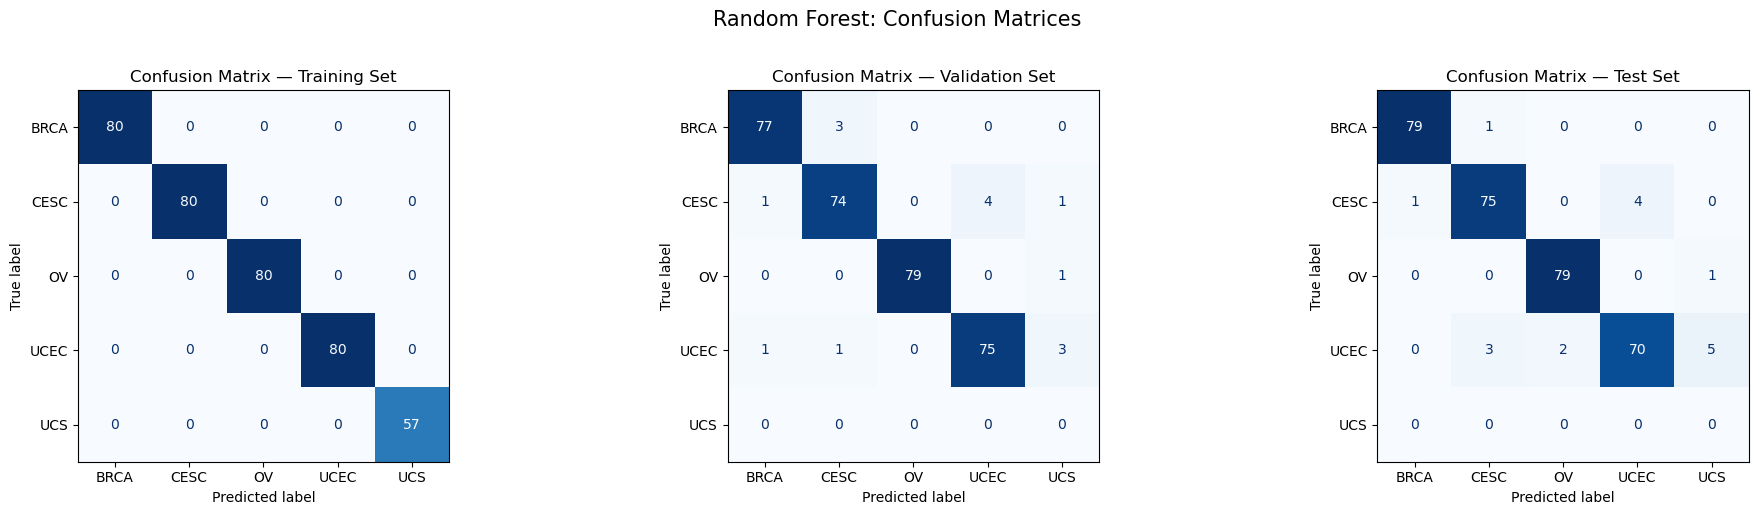


Classification Report — Test Set
              precision    recall  f1-score   support

        BRCA       0.99      0.99      0.99        80
        CESC       0.95      0.94      0.94        80
          OV       0.98      0.99      0.98        80
        UCEC       0.95      0.88      0.91        80
         UCS       0.00      0.00      0.00         0

    accuracy                           0.95       320
   macro avg       0.77      0.76      0.76       320
weighted avg       0.96      0.95      0.96       320



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:

# IMPROVED MODEL — RANDOM FOREST (better regularization)


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# load in the testing data sets
test_data     = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TEST_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
test_metadata = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TEST_SET_GSE62944_metadata.csv', index_col=0, header=0)

test_cancer_samples = test_metadata[test_metadata['cancer_type'].isin(cancer_type)].index
test_cancer_data    = test_data[test_cancer_samples]
test_gene_data      = test_cancer_data.loc[gene_list]

X_test = scaler.transform(test_gene_data.T)   # same scaler fit on training, no refit
y_test = test_metadata.loc[test_gene_data.T.index, 'cancer_type'].values

print(f"Test samples: {X_test.shape[0]}")

#  1. Grid search over Random Forest hyperparameters 
param_grid = {
    'n_estimators'     : [100, 200],      # number of trees
    'max_depth'        : [3, 5, 10, None],# None = fully grown trees
    'min_samples_leaf' : [2, 5, 10],      # regularization per tree
    'max_features'     : ['sqrt', 'log2'] # features considered per split
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV accuracy    : {grid_search.best_score_:.4f}")

rf_best = grid_search.best_estimator_

#  2. Compare original DT vs Random Forest 
dt_original = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=5,
    class_weight='balanced', random_state=42
).fit(X_train, y_train)

print("\n── Error Comparison ───────────────────────────────────")
for name, model in [("Original Decision Tree", dt_original),
                    ("Random Forest (refined)", rf_best)]:
    tr_err  = 1 - accuracy_score(y_train, model.predict(X_train))
    val_err = 1 - accuracy_score(y_val,   model.predict(X_val))
    print(f"\n  {name}")
    print(f"    In-sample error    (train) : {tr_err:.4f}  ({tr_err*100:.2f}%)")
    print(f"    Out-of-sample error  (val) : {val_err:.4f}  ({val_err*100:.2f}%)")

#  3. Final predictions on test set
y_test_pred   = rf_best.predict(X_test)
test_error    = 1 - accuracy_score(y_test, y_test_pred)
train_error   = 1 - accuracy_score(y_train, rf_best.predict(X_train))
val_error     = 1 - accuracy_score(y_val,   rf_best.predict(X_val))

print("\n── Final Random Forest Error Summary ──────────────────")
print(f"  In-sample error      (train) : {train_error:.4f}  ({train_error*100:.2f}%)")
print(f"  Out-of-sample error    (val) : {val_error:.4f}  ({val_error*100:.2f}%)")
print(f"  Test error            (test) : {test_error:.4f}  ({test_error*100:.2f}%)")

#  4. Confusion matrices 
class_order = sorted(np.unique(y_train))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (preds, true, title) in zip(
    axes,
    [(rf_best.predict(X_train), y_train, "Training Set"),
     (rf_best.predict(X_val),   y_val,   "Validation Set"),
     (y_test_pred,              y_test,  "Test Set")]
):
    cm   = confusion_matrix(true, preds, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix — {title}", fontsize=12)

plt.suptitle("Random Forest: Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 5. Classification report 
print("\nClassification Report — Test Set")
print("=" * 55)
print(classification_report(y_test, y_test_pred, target_names=class_order))


After the regularization and improvements, the out of sample accuracy increased to 95.31% compared to the original 76.56%. This indicates a much better model that is better equiped to work on new data sets. The regularization was able to reduce the over-fitting and accurately predict the type of gynelogical cancer based on gene expression. 

## Verify and validate your analysis: 

The average precision for the validation set was 0.83 for the original decision tree model. The average precision for the test set using the updated random forest model was 0.96. This is a 0.13 increase for precision between the two models when used on a data set besides the training data. This makes sense as the updated model reduced overall out of sample accuracy and should have a higher precision. Aditionally, the sikit learn API explains that the random forest classifier reduces overfitting compared to a regular decision tree model. This would indicate a better performance on our test data after the regularization was done. It controls the maximum number of sample sizes so the decision tree does not create too many branches that it can no longer generalize. 

## Conclusions and Ethical Implications: 

Overall, the model was pretty accurate at classifying the cancer type based on gene expression. This is a useful tool for doctors to utilize when looking at risk factors and diagnoses. However, misclassifying a cancer type could be very dangerous and lead to improper treatment. It is important to validate the results with other tests specific to each patient, especially for some of the cancers that were harder to identify (uterine and cervical). Finally, a lot of the training data is skewed toward older populations and majority white patients. This could lead to missing patterns in other demographics. 

## Limitations and Future Work: 

The model was initially subsetted to look at genes related to invasion and metastasis and how those could be used to identify a gynelogical cancer. In the future, a classification model could be built using genes related to all of the hallmarks and how they play a role. Those genes may be able to help further differentiate between some of the cancers that were hard to distinguish with this model, like uterine and cervical cancers). The model could also be trained against data sets with more diverse populations and equal amounts of each cancer type. Finally, a data set with more information about the hormonal contraceptive use would be helpful in determining any relationships between that history and presence of gynecological cancer. Most of the patients did not provide that history, making it difficult to draw any conclusions on that front. 

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*

# Citations

¹ Li, H., Wang, Q., Zhang, X., Liu, Y., & Zhao, W. (2023). Identification of novel key genes associated with uterine corpus endometrial carcinoma progression and prognosis. Annals of Translational Medicine, 11(3), 141. https://doi.org/10.21037/atm-22-6461

² National Cancer Institute. (2024). BRCA gene changes: Cancer risk and genetic testing fact sheet. https://www.cancer.gov/about-cancer/causes-prevention/genetics/brca-fact-sheet

³ Toss, A., Tomasello, C., Razzaboni, E., Contu, G., Grandi, G., Cagnacci, A., Schilder, R. J., & Cortesi, L. (2015). Hereditary ovarian cancer: Not only BRCA 1 and 2 genes. BioMed Research International, 2015, 341723. https://doi.org/10.1155/2015/341723

⁴ The Cancer Genome Atlas Research Network. (2017). Integrated molecular characterization of uterine carcinosarcoma. Cell, 171(2), 382–397.e20. https://doi.org/10.1016/j.ccell.2017.02.010

⁵ Liu, J., Nie, S., Li, S., et al. (2020). Methylation-driven genes and their prognostic value in cervical squamous cell carcinoma. Annals of Translational Medicine, 8, 868.